<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/owenabbata-hw3/2026/HW/OwenAbbata/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Homework 3 - Elevator Pressure

In this experiment I measured the change in the air pressure as I rode up the Clements Hall elevator (10 stories). The only challenge I faced was getting an undisturbed elevator ride, I solved this problem by going to Clements Hall at 9am on a tuesday 30 minutes before the classes usally start.

In [1]:
import numpy as np
import pandas as pa
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

,Time (s),Pressure (hPa)
0,-0.521728,1003.513565
1,0.509464,1003.512115
2,1.540633,1003.510590
3,2.571816,1003.509979
4,3.603021,1003.509979
5,3.797478,1003.509979
6,4.861865,1003.508682
7,5.926309,1003.507385
8,6.990772,1003.504944
9,8.055247,1003.495560


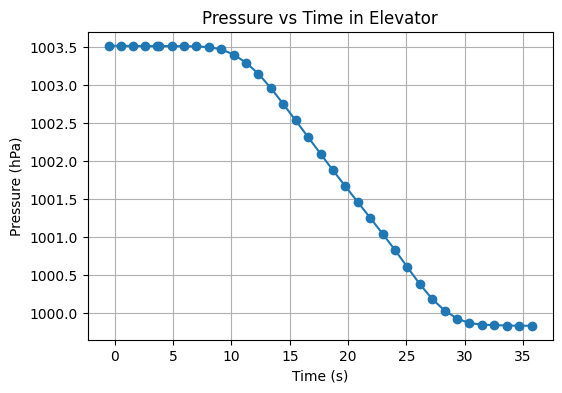

In [2]:
# Loading data
df = pa.read_csv('https://raw.githubusercontent.com/ubsuny/PHY386/refs/heads/owenabbata-hw3/2026/HW/OwenAbbata/Owenabbata_HW3_Data.csv')

# Display first 10 rows
display(df.head(10))

# Create a plot of Time (s) vs Pressure (hPa) using the DataFrame
plt.figure(figsize=(6, 4))
plt.plot(df['Time (s)'], df['Pressure (hPa)'], marker='o', linestyle='-')
plt.title('Pressure vs Time in Elevator')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (hPa)')
plt.grid(True)
plt.show()

In [3]:
# Check for missing values
df.isnull().sum()


,0
Time (s),0
Pressure (hPa),0


In [4]:
# Calculate the time differences between consecutive readings
time_diffs = df['Time (s)'].diff()

# Display the first 10 time differences
print("First 10 time differences (s):")
display(time_diffs.head(10))

# Display descriptive statistics of the time differences
print("\nDescriptive statistics of time differences (s):")
display(time_diffs.describe())

First 10 time differences (s):


,Time (s)
0,NaN
1,1.031192
2,1.031169
3,1.031183
4,1.031205
5,0.194457
6,1.064387
7,1.064444
8,1.064463
9,1.064475



Descriptive statistics of time differences (s):


,Time (s)
count,35.000000
mean,1.035783
std,0.146784
min,0.194457
25%,1.064404
50%,1.064441
75%,1.064460
max,1.064480


In [5]:
# Cut the DataFrame so it doesn't have the data where the elevator wasn't running
# We cut off the first 10.5 seconds and anything after 26.5 seconds because that is when the elevator was not moving
df_cut = df[(df['Time (s)'] > 10.5) & (df['Time (s)'] < 26.5)]


In [6]:
# Get descriptive statistics for the cut DataFrame
df_descriptive = df_cut.describe()

# Print mean, std, min, and max for Time (s) and Pressure (hPa)
print("Descriptive statistics for df_cut:")
display(df_descriptive.loc[['mean', 'std', 'min', 'max']])

Descriptive statistics for df_cut:


,Time (s),Pressure (hPa)
mean,18.699800,1001.880213
std,4.760325,0.942939
min,11.248641,1000.382233
max,26.150806,1003.291016


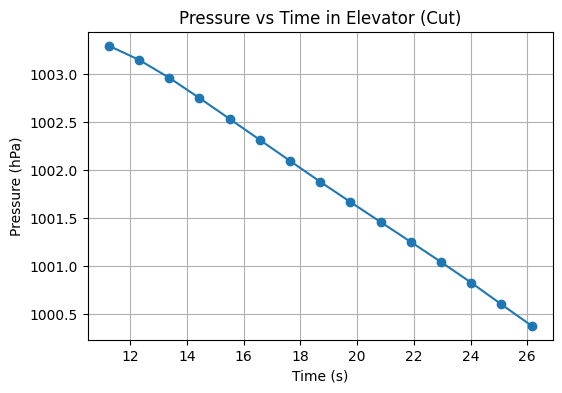

In [7]:
# Create a plot of Time (s) vs Pressure (hPa) using the cut DataFrame
plt.figure(figsize=(6,4))
plt.plot(df_cut['Time (s)'], df_cut['Pressure (hPa)'], marker='o', linestyle='-')
plt.title('Pressure vs Time in Elevator (Cut)')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (hPa)')
plt.grid(True)
plt.show()

In [8]:
# Calculate uncertainty (standard deviation) for Pressure and Time from the cut DataFrame
pressure_uncertainty = df_cut['Pressure (hPa)'].std()
time_uncertainty = df_cut['Time (s)'].std()

print(f"Uncertainty in Pressure (hPa): {pressure_uncertainty:.4f}")
print(f"Uncertainty in Time (s): {time_uncertainty:.4f}")

Uncertainty in Pressure (hPa): 0.9429
Uncertainty in Time (s): 4.7603


In [9]:
# Define elevator speed
elevator_speed = 1  # m/s

# Calculate height using h = v * t
df_cut['Height (m)'] = df_cut['Time (s)'] * elevator_speed

# Display the DataFrame with the new 'Height (m)' column
display(df_cut)

/tmp/ipykernel_769/4185951400.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['Height (m)'] = df_cut['Time (s)'] * elevator_speed


,Time (s),Pressure (hPa),Height (m)
12,11.248641,1003.291016,11.248641
13,12.313115,1003.144531,12.313115
14,13.377561,1002.958298,13.377561
15,14.442020,1002.747879,14.442020
16,15.506479,1002.531509,15.506479
17,16.570931,1002.313461,16.570931
18,17.635410,1002.094955,17.635410
19,18.699873,1001.878128,18.699873
20,19.764347,1001.668091,19.764347
21,20.828770,1001.460037,20.828770


In [10]:
# Calculate uncertainty in Height (m)
# Assuming elevator_speed (v) is constant and its uncertainty is negligible.
# The uncertainty in height (dH) = v * dTime, where dTime is time_uncertainty.
height_uncertainty = elevator_speed * time_uncertainty

print(f"Uncertainty in Height (m): {height_uncertainty:.4f}")

Uncertainty in Height (m): 4.7603


In [16]:
# Height in meters
H = 8500

def barometric_model(height, P0):
    """Calculates pressure using the barometric formula, with P0 as the parameter to fit.

    Parameters
    ----------
    height : float or array-like
        The height in meters.
    P0 : float
        The pressure at sea level (height = 0).

    """
    return P0 * np.exp(-height / H)

In [12]:
x_data = df_cut['Height (m)']
y_data = df_cut['Pressure (hPa)']

# Initial guess for P0 (pressure at height=0) can be the first pressure reading
p0_initial_guess = y_data.iloc[0]

# Fit the model
popt, pcov = curve_fit(barometric_model, x_data, y_data, p0=[p0_initial_guess])

# Display the optimal P0 value
optimal_P0 = popt[0]
print(f"Optimal P0 (hPa): {optimal_P0:.4f}")

Optimal P0 (hPa): 1004.0868


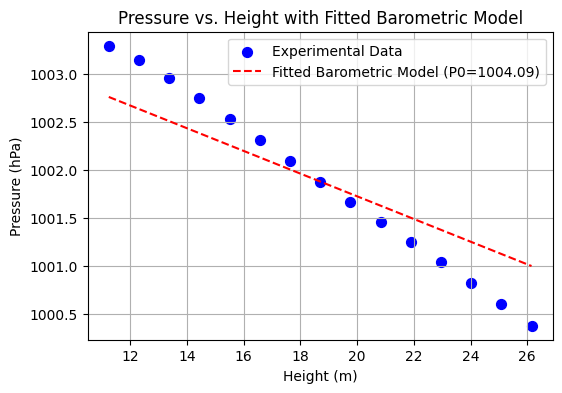

In [13]:
plt.figure(figsize=(6, 4))

# Plot experimental data
plt.scatter(x_data, y_data, label='Experimental Data', color='blue', marker='o', s=50)

# Generate height values for the fitted model
height_range = np.linspace(x_data.min(), x_data.max(), 100)

# Calculate corresponding pressure values using the fitted model
pressure_model = barometric_model(height_range, optimal_P0)

# Plot the fitted barometric model
plt.plot(height_range, pressure_model, label=f'Fitted Barometric Model (P0={optimal_P0:.2f})', color='red', linestyle='--')

plt.title('Pressure vs. Height with Fitted Barometric Model')
plt.xlabel('Height (m)')
plt.ylabel('Pressure (hPa)')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
std_err_P0 = np.sqrt(pcov[0, 0])
print(f"Uncertainty in P0 (hPa): {std_err_P0:.4f}")

Uncertainty in P0 (hPa): 0.0989


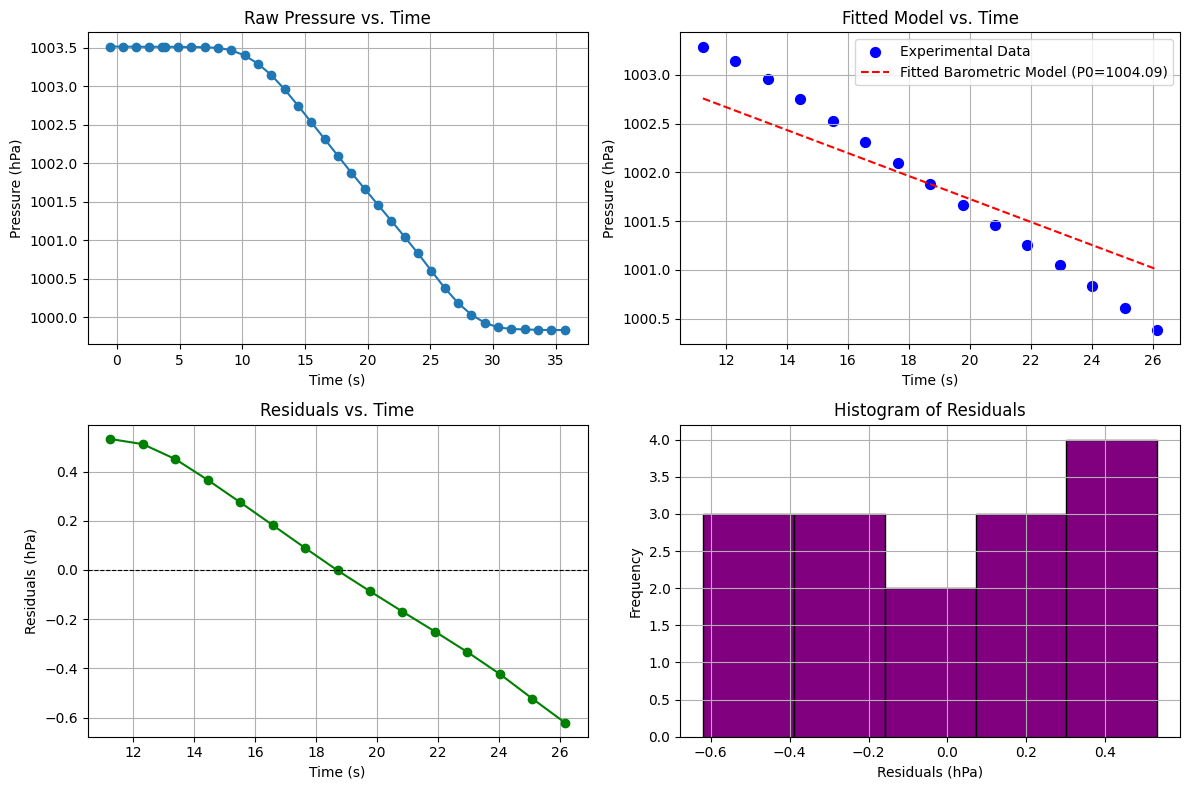

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: Raw Pressure vs. Time
axs[0, 0].plot(df['Time (s)'], df['Pressure (hPa)'], marker='o', linestyle='-')
axs[0, 0].set_title('Raw Pressure vs. Time')
axs[0, 0].set_xlabel('Time (s)')
axs[0, 0].set_ylabel('Pressure (hPa)')
axs[0, 0].grid(True)

# Top-right: Fitted Model vs. Time
axs[0, 1].scatter(df_cut['Time (s)'], df_cut['Pressure (hPa)'], label='Experimental Data', color='blue', s=50)
predicted_pressure_fitted_model = barometric_model(df_cut['Height (m)'], optimal_P0)
axs[0, 1].plot(df_cut['Time (s)'], predicted_pressure_fitted_model, label=f'Fitted Barometric Model (P0={optimal_P0:.2f})', color='red', linestyle='--')
axs[0, 1].set_title('Fitted Model vs. Time')
axs[0, 1].set_xlabel('Time (s)')
axs[0, 1].set_ylabel('Pressure (hPa)')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Bottom-left: Residuals vs. Time
residuals = df_cut['Pressure (hPa)'] - predicted_pressure_fitted_model
axs[1, 0].plot(df_cut['Time (s)'], residuals, marker='o', linestyle='-', color='green')
axs[1, 0].set_title('Residuals vs. Time')
axs[1, 0].set_xlabel('Time (s)')
axs[1, 0].set_ylabel('Residuals (hPa)')
axs[1, 0].axhline(0, color='black', linestyle='--', linewidth=0.8) # Add a zero line for reference
axs[1, 0].grid(True)

# Bottom-right: Histogram of Residuals
axs[1, 1].hist(residuals, bins=5, color='purple', edgecolor='black')
axs[1, 1].set_title('Histogram of Residuals')
axs[1, 1].set_xlabel('Residuals (hPa)')
axs[1, 1].set_ylabel('Frequency')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Parameter uncertainty
np.sqrt(np.diag(pcov))


array([0.09890614])


# Sensor Resolution:
According to https://phyphox.org/wiki/index.php?title=Sensor:_Pressure the sensor has a resolution of 0.1 hPa

This causes the sensor to not be able to determine the pressure difference in small height changes.

Sensor noise doesn't effect our fit because the sensor only take a few mesurments around every 0.7 seconds, due to this lack of mesurments its less likly to be noisey

# Systematic errors:
There should be very little systematic errors the only thing could be with sensor calibration as weather was cloudy and would have less effect inside the elevator.
Another error could be due to me moving my hand in the elevator cause the pressure to change. The pressence of me in the elevator could also have more effects on air pressure by me taking space and breathing.
#Comparison to theory:
The values for air pressure fall within the standard buffalo air pressure of 1000-1004 hPa.